# Jetson DLA vs GPU 소비 전력 분석

YOLOv8m INT8 추론 중 측정한 INA3221 전력 데이터를 시각화합니다.

| 항목 | 내용 |
|---|---|
| DLA | `power_dla.csv` — DLA Core 0 INT8 |
| GPU | `power_gpu.csv` — GPU INT8 |
| x축 | 경과 시간 (s) |
| y축 | 소비 전력 (W) |

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "axes.titlesize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    # 배경 흰색 고정 (Jupyter Lab 다크 테마 무시)
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    # 텍스트·축 색상 명시 (다크 테마에서 투명/흰색으로 바뀌는 것 방지)
    "text.color":         "black",
    "axes.labelcolor":    "black",
    "xtick.color":        "black",
    "ytick.color":        "black",
    "axes.edgecolor":     "black",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    "grid.alpha":         0.6,
    "grid.color":         "0.5",
    "lines.linewidth":    1.4,
    "figure.dpi":         120,
})

# 실제 사용 폰트 확인
import matplotlib.font_manager as fm
serif_fonts = sorted(set(f.name for f in fm.fontManager.ttflist if "Times" in f.name))
print(f"Times 계열 폰트: {serif_fonts if serif_fonts else '없음 → Liberation/DejaVu Serif 사용'}")

COLOR_DLA = "#2166ac"   # 청색
COLOR_GPU = "#d6604d"   # 적색

Times 계열 폰트: ['Times New Roman']


## CSV 로드

시계열 구간(빈 행 이전)만 읽어 `elapsed_s`와 각 레일별 `*_mW`, `total_mW` 컬럼을 추출합니다.

In [2]:
def load_power_csv(path: str) -> pd.DataFrame:
    """빈 행(통계 구분선) 이전의 시계열 데이터만 DataFrame으로 반환."""
    rows = []
    header = None
    with open(path, newline="") as f:
        for row in csv.reader(f):
            if not row or all(c.strip() == "" for c in row):
                break
            if header is None:
                header = row
            else:
                rows.append(row)
    df = pd.DataFrame(rows, columns=header)
    return df.apply(pd.to_numeric, errors="coerce")

dla = load_power_csv("power_dla.csv")
gpu = load_power_csv("power_gpu.csv")

rail_cols = [c for c in dla.columns if c.endswith("_mW") and c != "total_mW"]
rail_names = [c[:-3] for c in rail_cols]

print(f"DLA : {len(dla)}샘플  경과={dla['elapsed_s'].max():.1f}s  "
      f"총 전력 평균={dla['total_mW'].mean() / 1000:.3f} W")
print(f"GPU : {len(gpu)}샘플  경과={gpu['elapsed_s'].max():.1f}s  "
      f"총 전력 평균={gpu['total_mW'].mean() / 1000:.3f} W")
print(f"\n레일: {rail_names}")
dla.head(3)

DLA : 128샘플  경과=64.2s  총 전력 평균=22.074 W
GPU : 97샘플  경과=48.6s  총 전력 평균=28.585 W

레일: ['VDD_GPU_SOC', 'VDD_CPU_CV', 'VIN_SYS_5V0', 'VDDQ_VDD2_1V8AO']


,timestamp,elapsed_s,VDD_GPU_SOC_mV,VDD_GPU_SOC_mA,VDD_GPU_SOC_mW,VDD_CPU_CV_mV,VDD_CPU_CV_mA,VDD_CPU_CV_mW,VIN_SYS_5V0_mV,VIN_SYS_5V0_mA,VIN_SYS_5V0_mW,VDDQ_VDD2_1V8AO_mV,VDDQ_VDD2_1V8AO_mA,VDDQ_VDD2_1V8AO_mW,total_mW
0,1.779361e+09,0.000,20040.0,280.0,5611.2,20048.0,180.0,3608.6,5048.0,1140.0,5754.7,5048.0,280.0,1413.4,16388.0
1,1.779361e+09,0.506,20040.0,280.0,5611.2,20048.0,200.0,4009.6,5048.0,1160.0,5855.7,5048.0,300.0,1514.4,16990.9
2,1.779361e+09,1.012,20040.0,280.0,5611.2,20040.0,240.0,4809.6,5048.0,1140.0,5754.7,5048.0,280.0,1413.4,17589.0


## 총 소비 전력 시계열 (DLA vs GPU)

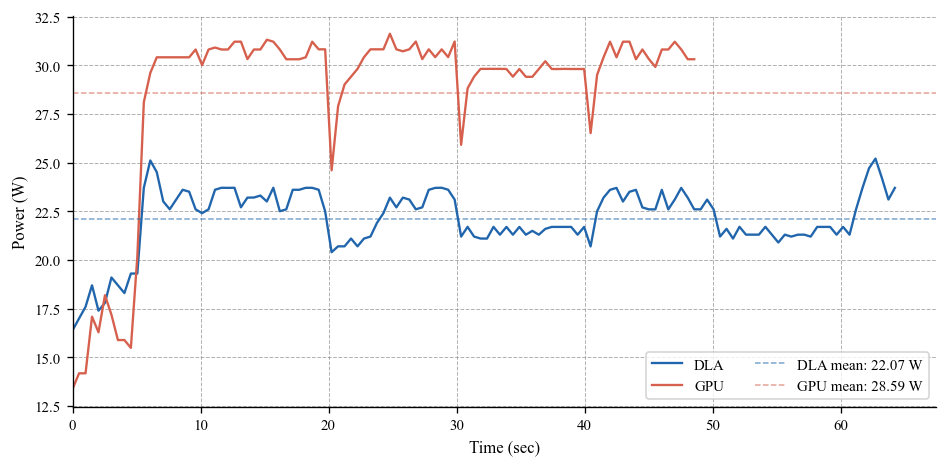

저장: power_total.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dla["elapsed_s"], dla["total_mW"] / 1000,
        color=COLOR_DLA, label="DLA")
ax.plot(gpu["elapsed_s"], gpu["total_mW"] / 1000,
        color=COLOR_GPU, label="GPU", alpha=1)

avg_dla = dla["total_mW"].mean() / 1000
avg_gpu = gpu["total_mW"].mean() / 1000
ax.axhline(avg_dla, color=COLOR_DLA, ls="--", lw=0.9, alpha=0.6,
           label=f"DLA mean: {avg_dla:.2f} W")
ax.axhline(avg_gpu, color=COLOR_GPU, ls="--", lw=0.9, alpha=0.6,
           label=f"GPU mean: {avg_gpu:.2f} W")

reduction = (avg_gpu - avg_dla) / avg_gpu * 100
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Power (W)")
#ax.set_title(f"Total Power Consumption — DLA vs GPU  (DLA saves {reduction:.1f}% vs GPU)")
ax.set_xlim(left=0)
#ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
ax.grid(True)
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("power_total.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: power_total.png")

## 레일별 소비 전력 시계열

각 전력 레일(VDD_CPU_CV, VIN_SYS_5V0, VDDQ_VDD2_1V8AO 등)의 시계열을 DLA·GPU 별로 표시합니다.

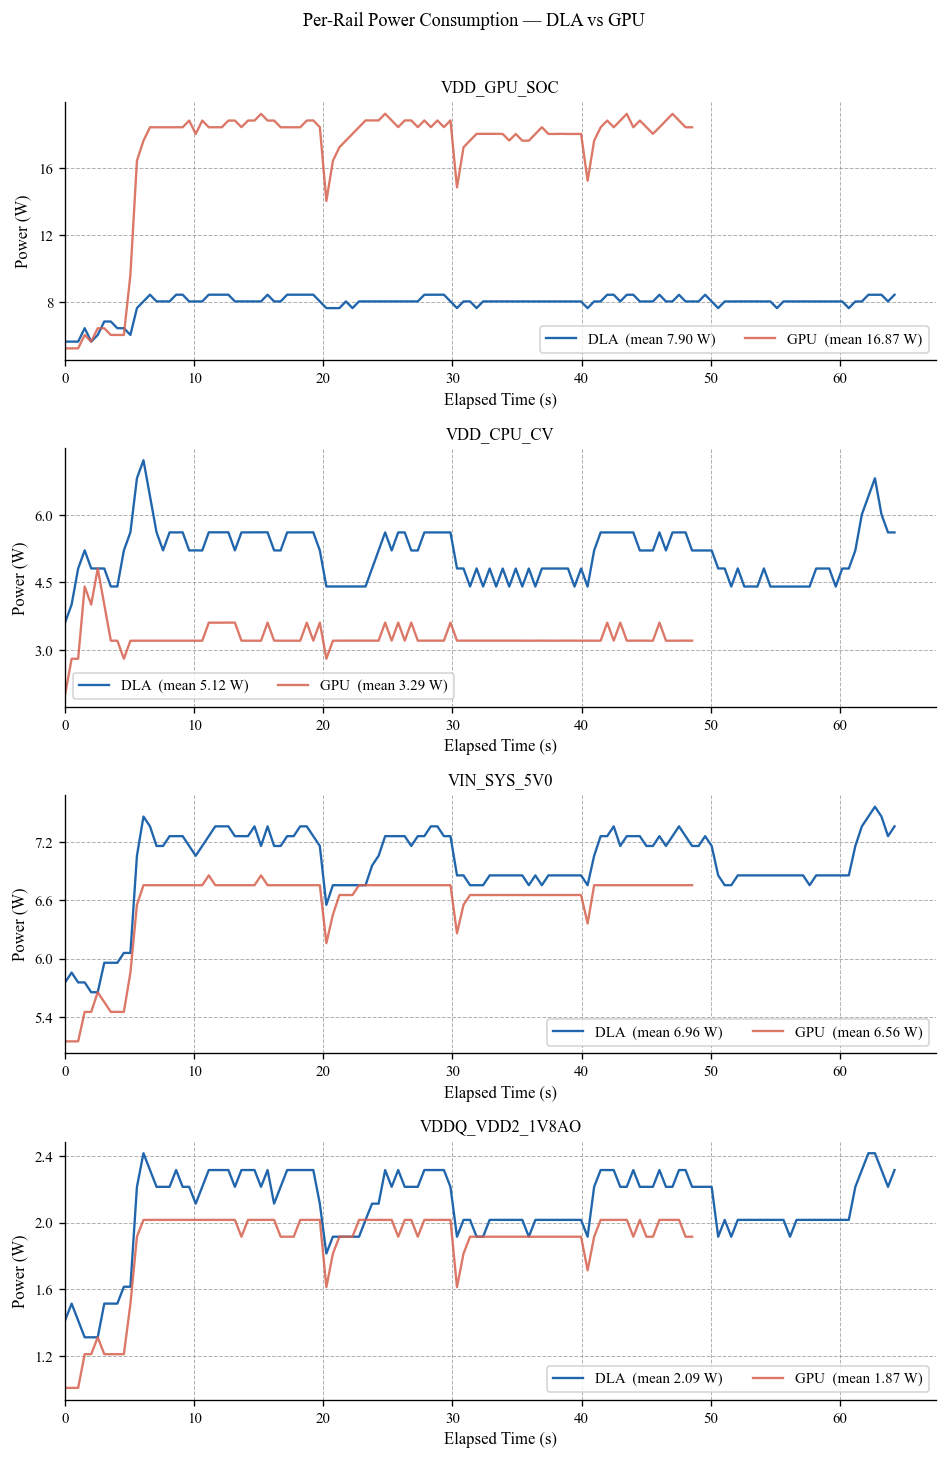

저장: power_rails.png


In [4]:
n = len(rail_names)
fig, axes = plt.subplots(n, 1, figsize=(8, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, col, name in zip(axes, rail_cols, rail_names):
    ax.plot(dla["elapsed_s"], dla[col] / 1000,
            color=COLOR_DLA, label=f"DLA  (mean {dla[col].mean() / 1000:.2f} W)")
    ax.plot(gpu["elapsed_s"], gpu[col] / 1000,
            color=COLOR_GPU, label=f"GPU  (mean {gpu[col].mean() / 1000:.2f} W)", alpha=0.85)
    ax.set_xlabel("Elapsed Time (s)")
    ax.set_ylabel("Power (W)")
    ax.set_title(name)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.grid(True)
    ax.legend(ncol=2)

plt.suptitle("Per-Rail Power Consumption — DLA vs GPU", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("power_rails.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: power_rails.png")